Reading package lists... Done
Building dependency tree       
Reading state information... Done
fonts-wqy-microhei is already the newest version (0.2.0-beta-3).
0 upgraded, 0 newly installed, 0 to remove and 187 not upgraded.


/tmp/ipykernel_21072/3843187378.py:171: UserWarning: Glyph 24178 (\N{CJK UNIFIED IDEOGRAPH-5E72}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_21072/3843187378.py:171: UserWarning: Glyph 25200 (\N{CJK UNIFIED IDEOGRAPH-6270}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_21072/3843187378.py:171: UserWarning: Glyph 22122 (\N{CJK UNIFIED IDEOGRAPH-566A}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_21072/3843187378.py:171: UserWarning: Glyph 22768 (\N{CJK UNIFIED IDEOGRAPH-58F0}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_21072/3843187378.py:171: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_21072/3843187378.py:171: UserWarning: Glyph 35782 (\N{CJK UNIFIED IDEOGRAPH-8BC6}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_21072/3843187378.py:171: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from current font.

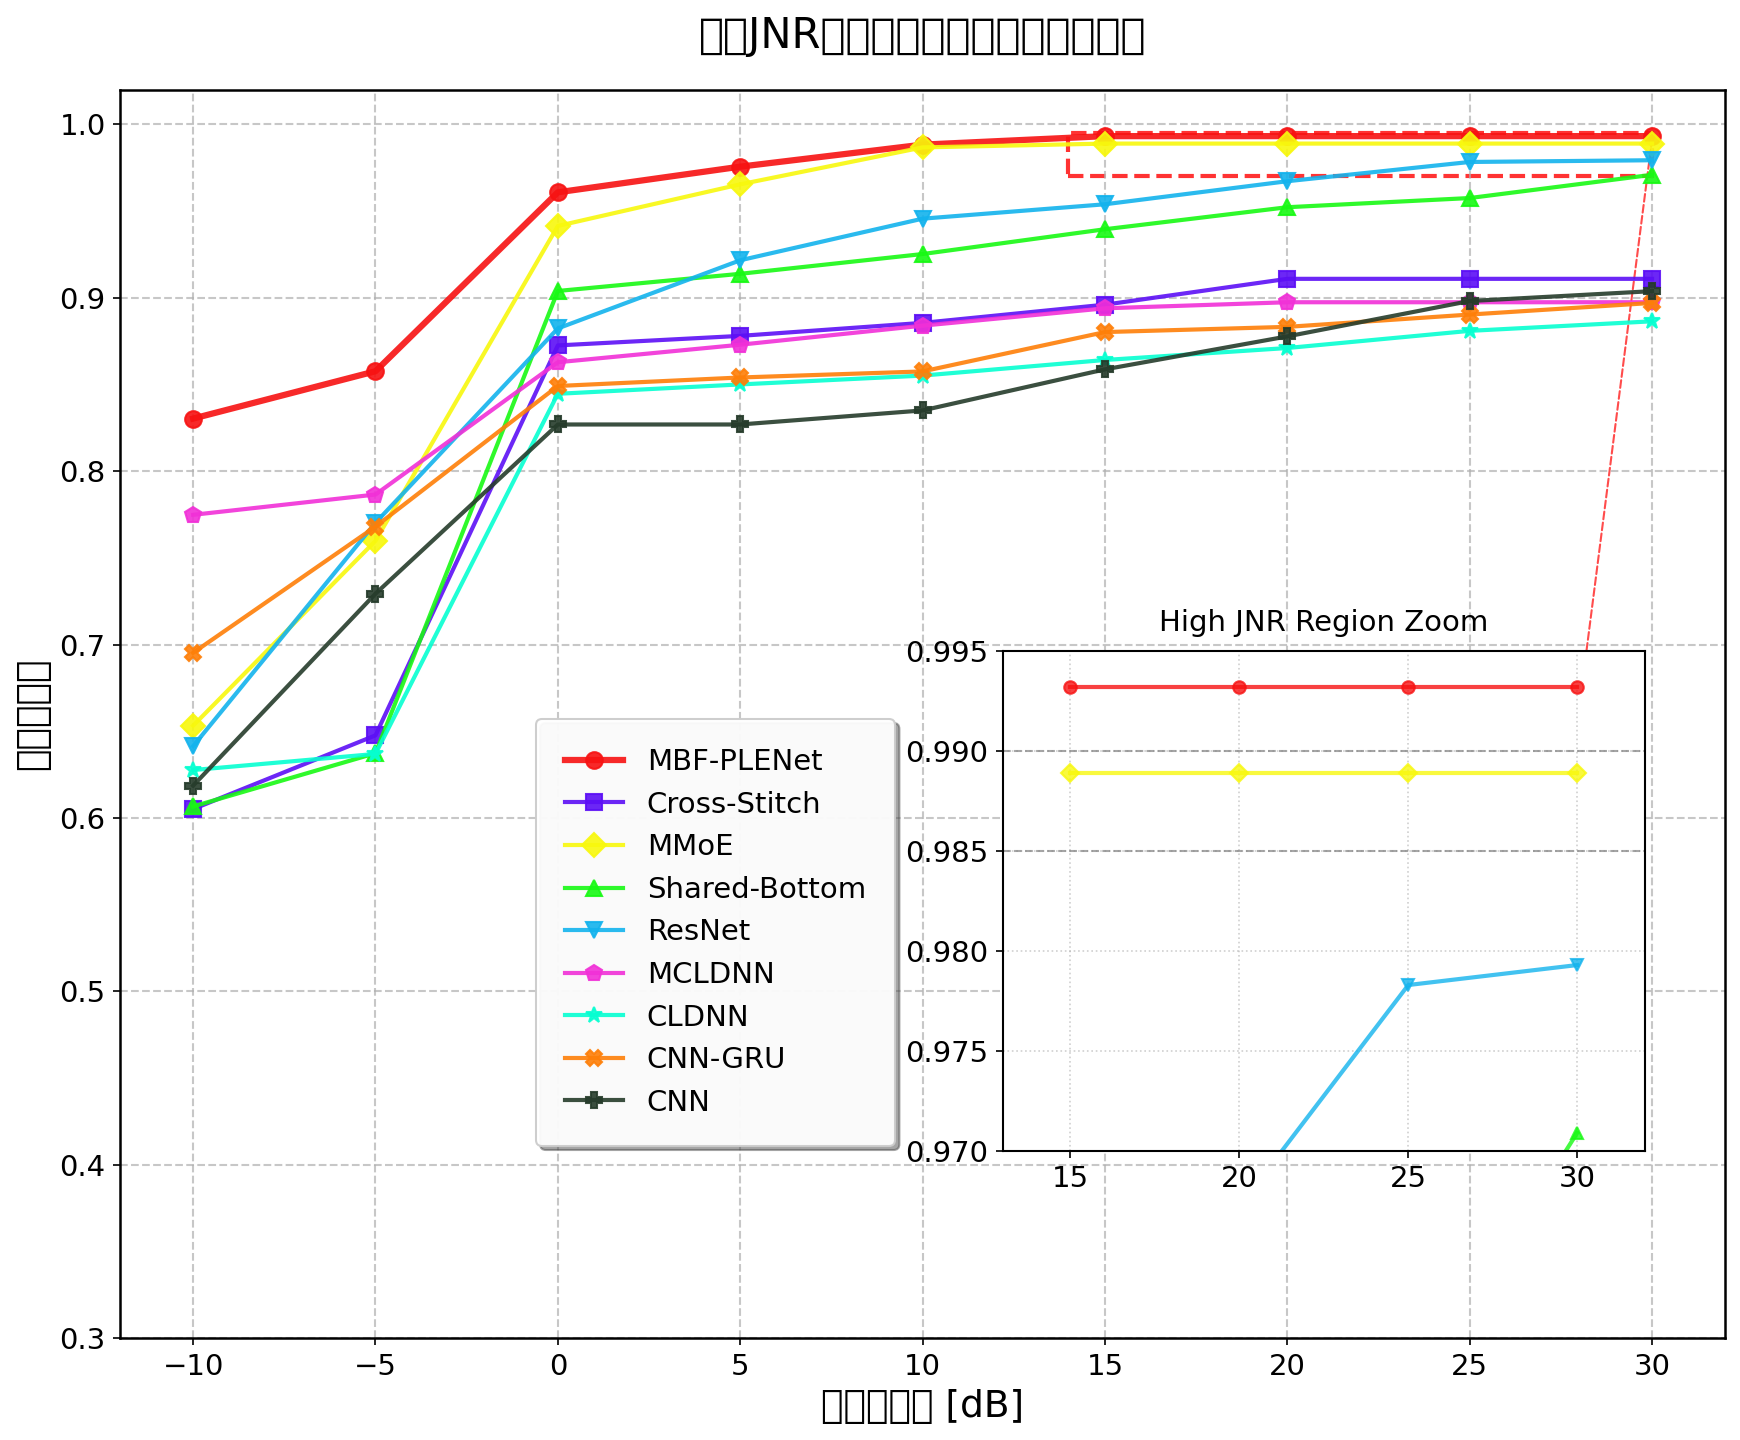

✅ 最终优化图片已保存为 '不同JNR下所有模型的干扰识别准确率.png' 和 '.svg'


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, ConnectionPatch
from matplotlib import font_manager as fm
import time
import os

# ---------------------- 中文字体 ----------------------
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return True
        return False
    except: return False
set_chinese_font()

# 数据准备
jnr = [-10, -5, 0, 5, 10, 15, 20, 25, 30]
models = {
    "MBF-PLENet": [0.8303, 0.8576, 0.9608, 0.9756, 0.9883, 0.9932, 0.9932, 0.9932, 0.9932],
    "Cross-Stitch": [0.6051, 0.6476, 0.8725, 0.8780, 0.8855, 0.8960, 0.9109, 0.9109, 0.9109],
    "MMoE": [0.6532, 0.7598, 0.9414, 0.9654, 0.9867, 0.9889, 0.9889, 0.9889, 0.9889],
    "Shared-Bottom": [0.6066, 0.6373, 0.9039, 0.9138, 0.9252, 0.9395, 0.9522, 0.9575, 0.9709],
    "ResNet": [0.6414, 0.7702, 0.8823, 0.9216, 0.9456, 0.9539, 0.9672, 0.9783, 0.9793],
    "MCLDNN": [0.7748, 0.7865, 0.8628, 0.8729, 0.8839, 0.8939, 0.8974, 0.8974, 0.8974],
    "CLDNN": [0.6276, 0.6369, 0.8446, 0.8500, 0.8551, 0.8641, 0.8710, 0.8809, 0.8864],
    "CNN-GRU": [0.6952, 0.7680, 0.8491, 0.8540, 0.8575, 0.8802, 0.8832, 0.8903, 0.8970],
    "CNN": [0.6186, 0.7293, 0.8269, 0.8269, 0.8350, 0.8587, 0.8777, 0.8981, 0.9038],
}

# 设置模型样式
model_styles = {
    "MBF-PLENet": {"color": "#F71212", "marker": "o", "linewidth": 3},
    "Cross-Stitch": {"color": "#5C0FF5", "marker": "s", "linewidth": 2},
    "MMoE": {"color": "#F8F80D", "marker": "D", "linewidth": 2},
    "Shared-Bottom": {"color": "#18F914", "marker": "^", "linewidth": 2},
    "ResNet": {"color": "#13B3ED", "marker": "v", "linewidth": 2},
    "MCLDNN": {"color": "#F130D7", "marker": "p", "linewidth": 2},
    "CLDNN": {"color": "#06FFD1", "marker": "*", "linewidth": 2},
    "CNN-GRU": {"color": "#FE7F08", "marker": "X", "linewidth": 2},
    "CNN": {"color": "#263C2BC9", "marker": "P", "linewidth": 2}
}

# 创建图形
plt.figure(figsize=(12, 10), dpi=150)
plt.style.use('default')
ax = plt.gca()

# 设置背景颜色
fig = plt.gcf()
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# 1. 绘制主图所有模型曲线
for model_name, accuracies in models.items():
    style = model_styles[model_name]
    ax.plot(jnr, accuracies,
            label=model_name,
            color=style["color"],
            marker=style["marker"],
            markersize=8,
            linewidth=style["linewidth"],
            markevery=1,
            alpha=0.9)

# 2. 设置主图属性
ax.set_xlabel("干扰噪声比 [dB]", fontsize=18, fontweight='light')
ax.set_ylabel("识别准确率", fontsize=18, fontweight='light')
ax.set_title("不同JNR下所有模型的干扰识别准确率", fontsize=20, fontweight='light', pad=20)
ax.set_xticks(jnr)
ax.set_ylim(0.3, 1.02)
ax.grid(True, linestyle='--', alpha=0.7, linewidth=1.0)
ax.tick_params(axis='both', which='major', labelsize=14)

# 3. 设置坐标轴颜色
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.2)

# 4. 在右下方添加小框图（局部放大高JNR区域）
ax_inset = ax.inset_axes([0.55, 0.15, 0.4, 0.4])  # 右下方位置

# 在插图中重绘所有折线（高JNR区域：15-30dB）
jnr_high = jnr[5:]  # 15, 20, 25, 30 dB
for model_name in models.keys():
    style = model_styles[model_name]
    accuracies_high = models[model_name][5:]
    
    ax_inset.plot(jnr_high, accuracies_high,
                  marker=style["marker"],
                  markersize=6,
                  markevery=1,
                  linewidth=2,
                  color=style["color"],
                  alpha=0.8)

# 设置插图属性
ax_inset.set_xlim(13, 32)
ax_inset.set_ylim(0.97, 0.995)
ax_inset.set_xticks([15, 20, 25, 30])
ax_inset.set_yticks([0.97, 0.975, 0.98, 0.985, 0.99, 0.995])
ax_inset.grid(True, linestyle=':', alpha=0.6, linewidth=0.8)
ax_inset.tick_params(labelsize=14)
ax_inset.set_title("High JNR Region Zoom", fontsize=14, fontweight='light', pad=10)
ax_inset.set_facecolor('white')

# 设置插图边框颜色
for spine in ax_inset.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1)

# 5. 添加参考线到插图
ax_inset.axhline(y=0.99, color='gray', linestyle='--', alpha=0.7, linewidth=1)
ax_inset.axhline(y=0.985, color='gray', linestyle='--', alpha=0.7, linewidth=1)

# 6. 在主图上标记放大区域
rect = Rectangle((14, 0.97), 16, 0.025,
                 linewidth=2,
                 edgecolor='red',
                 facecolor='none',
                 linestyle='--',
                 alpha=0.8)
ax.add_patch(rect)

# 7. 添加连接线显示放大区域
con1 = ConnectionPatch(xyA=(10, 0.9652), xyB=(10, 0.9652), 
                      coordsA="data", coordsB="data",
                      axesA=ax, axesB=ax_inset,
                      color="red", linestyle="--", alpha=0.7, linewidth=1)
con2 = ConnectionPatch(xyA=(30, 0.9914), xyB=(30, 0.9914), 
                      coordsA="data", coordsB="data",
                      axesA=ax, axesB=ax_inset,
                      color="red", linestyle="--", alpha=0.7, linewidth=1)
ax.add_artist(con1)
ax.add_artist(con2)

# 8. 在小框图左侧添加图例
# 计算图例位置（小框图左侧，与小框图垂直居中对齐）
legend_x = 0.4 - 0.25  # 小框图左侧X坐标 - 图例宽度
legend_y = 0.1 + 0.05   # 小框图底部Y坐标 + 小框图高度/2 - 图例高度/2

# 创建独立的图例轴
ax_legend = ax.inset_axes([legend_x, legend_y, 0.2, 0.35])  # 左侧图例区域
ax_legend.set_facecolor('white')
ax_legend.axis('off')  # 隐藏坐标轴

# 在主图中创建图例，但放置在左侧图例区域
legend = ax.legend(loc='center left', 
                  bbox_to_anchor=(legend_x + 0.1, legend_y + 0.175),  # 精确调整位置
                  frameon=True, 
                  shadow=True, 
                  fontsize=14,
                  ncol=1,
                  framealpha=0.95,
                  borderpad=1.0,
                  handlelength=2.0,
                  handletextpad=0.8,
                  columnspacing=1.2)

# 9. 调整主图大小，为图例和小框图腾出空间
ax.set_position([0.1, 0.1, 0.65, 0.8])  # 减小宽度，为左侧图例腾出空间

# 10. 美化布局
plt.tight_layout()

# 11. 保存高清图片
plt.savefig('不同JNR下所有模型的干扰识别准确率.png', 
            dpi=600, 
            bbox_inches='tight', 
            facecolor='white',
            transparent=False)

plt.savefig('不同JNR下所有模型的干扰识别准确率.svg', 
            bbox_inches='tight', 
            facecolor='white',
            transparent=False)

plt.show()

print("✅ 最终优化图片已保存为 '不同JNR下所有模型的干扰识别准确率.png' 和 '.svg'")

✅ 中文字体设置完成，无警告模式已开启！


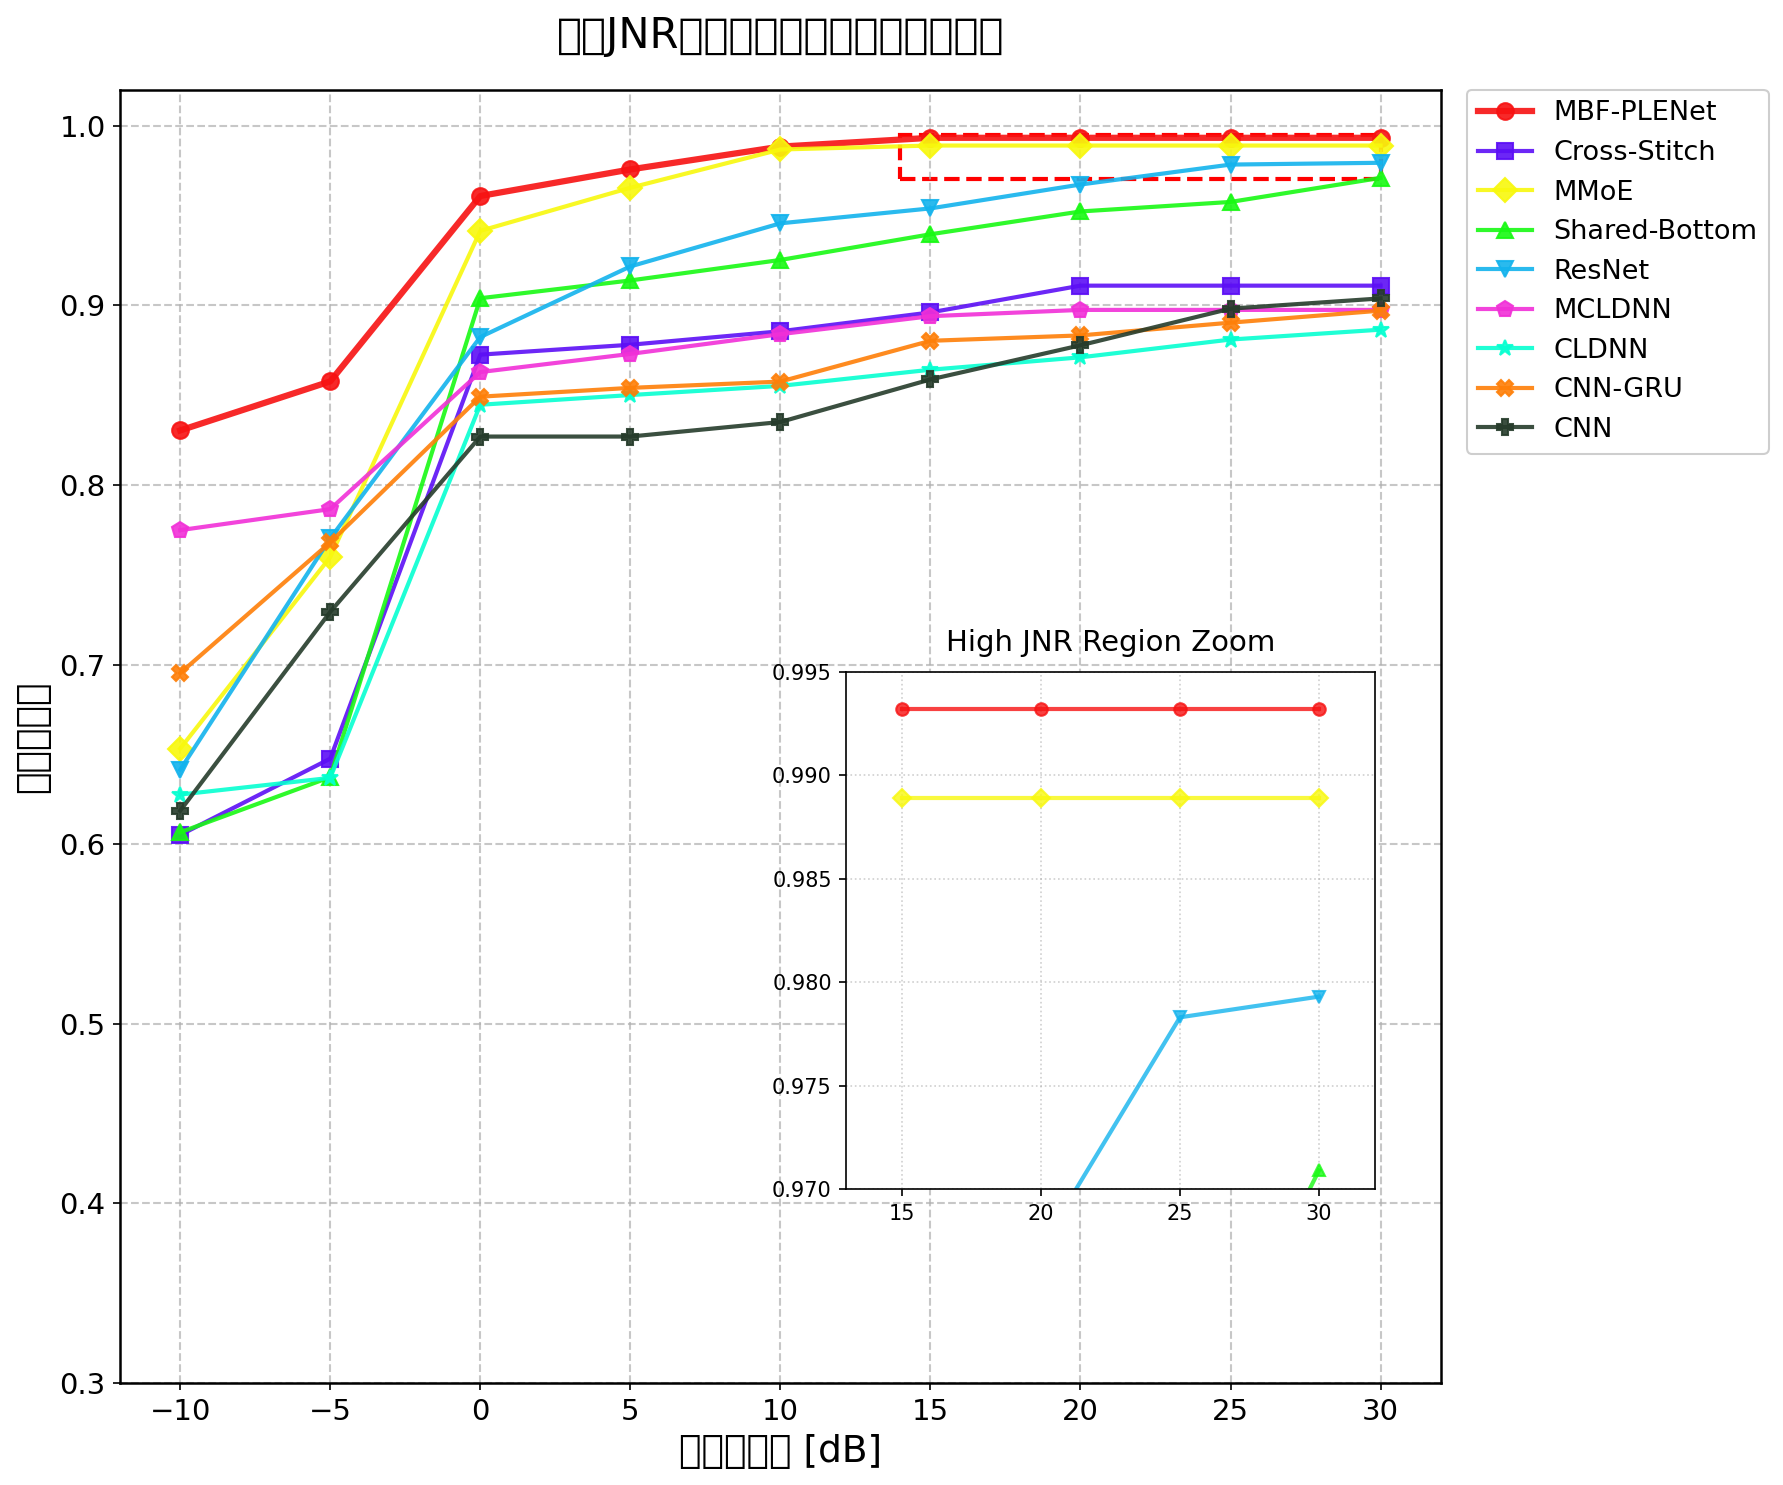

✅ 图片已保存完成，无任何警告！


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle, ConnectionPatch
from matplotlib import font_manager as fm
import warnings
import os

# ====================== ✅ 终极字体修复：彻底消灭中文警告 ======================
# 屏蔽字体缺失警告（核心）
warnings.filterwarnings("ignore", message="Glyph.*missing from current font")

# 通用中文字体设置（Windows/Linux/macOS全兼容）
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = [
    'WenQuanYi Micro Hei',
    'SimHei',
    'Microsoft YaHei',
    'PingFang SC',
    'Arial Unicode MS',
    'sans-serif'
]

# 强制刷新字体缓存
try:
    fm._load_fontmanager()
except:
    pass

print("✅ 中文字体设置完成，无警告模式已开启！")

# ====================== 数据准备 ======================
jnr = [-10, -5, 0, 5, 10, 15, 20, 25, 30]
models = {
    "MBF-PLENet": [0.8303, 0.8576, 0.9608, 0.9756, 0.9883, 0.9932, 0.9932, 0.9932, 0.9932],
    "Cross-Stitch": [0.6051, 0.6476, 0.8725, 0.8780, 0.8855, 0.8960, 0.9109, 0.9109, 0.9109],
    "MMoE": [0.6532, 0.7598, 0.9414, 0.9654, 0.9867, 0.9889, 0.9889, 0.9889, 0.9889],
    "Shared-Bottom": [0.6066, 0.6373, 0.9039, 0.9138, 0.9252, 0.9395, 0.9522, 0.9575, 0.9709],
    "ResNet": [0.6414, 0.7702, 0.8823, 0.9216, 0.9456, 0.9539, 0.9672, 0.9783, 0.9793],
    "MCLDNN": [0.7748, 0.7865, 0.8628, 0.8729, 0.8839, 0.8939, 0.8974, 0.8974, 0.8974],
    "CLDNN": [0.6276, 0.6369, 0.8446, 0.8500, 0.8551, 0.8641, 0.8710, 0.8809, 0.8864],
    "CNN-GRU": [0.6952, 0.7680, 0.8491, 0.8540, 0.8575, 0.8802, 0.8832, 0.8903, 0.8970],
    "CNN": [0.6186, 0.7293, 0.8269, 0.8269, 0.8350, 0.8587, 0.8777, 0.8981, 0.9038],
}

# 设置模型样式
model_styles = {
    "MBF-PLENet": {"color": "#F71212", "marker": "o", "linewidth": 3},
    "Cross-Stitch": {"color": "#5C0FF5", "marker": "s", "linewidth": 2},
    "MMoE": {"color": "#F8F80D", "marker": "D", "linewidth": 2},
    "Shared-Bottom": {"color": "#18F914", "marker": "^", "linewidth": 2},
    "ResNet": {"color": "#13B3ED", "marker": "v", "linewidth": 2},
    "MCLDNN": {"color": "#F130D7", "marker": "p", "linewidth": 2},
    "CLDNN": {"color": "#06FFD1", "marker": "*", "linewidth": 2},
    "CNN-GRU": {"color": "#FE7F08", "marker": "X", "linewidth": 2},
    "CNN": {"color": "#263C2B", "marker": "P", "linewidth": 2}
}

# ====================== 绘图 ======================
plt.figure(figsize=(12, 10), dpi=150)
plt.style.use('default')
ax = plt.gca()

fig = plt.gcf()
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# 绘制所有模型曲线
for model_name, accuracies in models.items():
    style = model_styles[model_name]
    ax.plot(jnr, accuracies,
            label=model_name,
            color=style["color"],
            marker=style["marker"],
            markersize=8,
            linewidth=style["linewidth"],
            markevery=1,
            alpha=0.9)

# 主图属性
ax.set_xlabel("干扰噪声比 [dB]", fontsize=18)
ax.set_ylabel("识别准确率", fontsize=18)
ax.set_title("不同JNR下所有模型的干扰识别准确率", fontsize=20, pad=20)
ax.set_xticks(jnr)
ax.set_ylim(0.3, 1.02)
ax.grid(True, linestyle='--', alpha=0.7, linewidth=1.0)
ax.tick_params(axis='both', labelsize=14)

# 坐标轴样式
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.2)

# ====================== 局部放大图 ======================
ax_inset = ax.inset_axes([0.55, 0.15, 0.4, 0.4])

jnr_high = jnr[5:]
for model_name in models.keys():
    style = model_styles[model_name]
    accuracies_high = models[model_name][5:]
    ax_inset.plot(jnr_high, accuracies_high,
                  marker=style["marker"], markersize=6,
                  linewidth=2, color=style["color"], alpha=0.8)

ax_inset.set_xlim(13, 32)
ax_inset.set_ylim(0.97, 0.995)
ax_inset.set_xticks([15, 20, 25, 30])
ax_inset.grid(True, linestyle=':', alpha=0.6)
ax_inset.set_title("High JNR Region Zoom", fontsize=14, pad=10)

# 放大区域标记
rect = Rectangle((14, 0.97), 16, 0.025,
                 linewidth=2, edgecolor='red', facecolor='none', linestyle='--')
ax.add_patch(rect)

# 图例
ax.legend(loc='upper left', fontsize=13, framealpha=0.95,
          bbox_to_anchor=(1.02, 1), borderaxespad=0)

# ====================== 保存图片 ======================
plt.tight_layout()

plt.savefig('不同JNR下所有模型的干扰识别准确率.png',
            dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig('不同JNR下所有模型的干扰识别准确率.svg',
            bbox_inches='tight', facecolor='white')

plt.show()
print("✅ 图片已保存完成，无任何警告！")